# Spotify Recommender System – Part 2: Popularity Baseline
**Author:** Miguel Vásquez  
**Date:** 20 September 2025  
**Updated:** 4 October 2025

---

## 1. Introduction  

As a first benchmark, we implement a **popularity-based recommender system**.
This simple heuristic recommends tracks that occur most frequently across all playlists, regardless of individual user preferences.

Although lacking personalization, this baseline is crucial: it establishes a **lower-bound performance reference** to evaluate improvements achieved by more sophisticated models such as collaborative filtering or hybrid recommenders.

During this project we actually explored **two iterations** of the baseline:
- An **initial artisanal version** with a handcrafted split and playlist-level evaluation.
- A **revised version** integrated with our current pipeline (using item2idx.pkl and consistent train/test splits), allowing direct comparison with ALS and future models.

This notebook documents the latter, while also reflecting on the evolution of our approach.

---

## 2. Objectives of this notebook  

1. **Load preprocessed data** from `03_data_prep.ipynb`.
2. **Compute global track popularity** based on frequency across training playlists.
3. **Generate Top-K recommendations** directly from the popularity ranking.
4. **Evaluate performance** with ranking-aware metrics:
    - Precision@K
    - Recall@K
    - Hit Rate@K
    - NDCG@K

---

## 3. Load Data
We load the processed subset of playlists and verify consistency.
Data checks include:
- Missing values
- Duplicate rows
- Column validation (playlist_id, artist_name, track_name)

This ensures the dataset is clean and ready for the popularity computation.

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import pickle
from IPython.display import display, Markdown

# Ensure working directory is project root
display(Markdown(f"Current working directory: {os.getcwd()}"))
if os.getcwd().endswith("notebooks"):
    os.chdir("..")
    display(Markdown(f"Changed working directory to: {os.getcwd()}"))

#Load data
from src.load_data import load_data
processed_dir = Path("data/processed")
train_csr, test_csr, interactions, wmat = load_data(processed_dir, weighting="tfidf")
print(f"train: {train_csr.shape}, test: {test_csr.shape}, wmat: {wmat.shape}")


# Paths
with open("data/processed/item2idx.pkl", "rb") as f:
    item2idx = pickle.load(f)

idx2item = {v: k for k, v in item2idx.items()}

display(Markdown(f"Number of items: {len(item2idx)}"))

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)
pop_path = models_dir / "popularity_model.csv"

# Load the subset of flattened tracks
tracks_df = pd.read_parquet("data/subset/tracks_subset.parquet")
display(tracks_df.head())

Current working directory: c:\Users\Miguel\portfolio\Spotify-Recommender-System\notebooks

Changed working directory to: c:\Users\Miguel\portfolio\Spotify-Recommender-System

train: (500000, 1614034), test: (500000, 1614034), wmat: (1614034, 500000)


Number of items: 1614034

,playlist_id,track_uri,track_name,artist_name
0,0,0UaMYEvWZi0ZqiDOoHU3YI,Lose Control (feat. Ciara & Fat Man Scoop),Missy Elliott
1,0,6I9VzXrHxO9rA9A5euc8Ak,Toxic,Britney Spears
2,0,0WqIKmW4BTrj3eJFmnCKMv,Crazy In Love,Beyoncé
3,0,1AWQoqb9bSvzTjaLralEkT,Rock Your Body,Justin Timberlake
4,0,1lzr43nnXAijIGYnCT8M8H,It Wasn't Me,Shaggy


## 4. Popularity Model
### 4.1 Global track popularity
We compute frequency of each track across all playlists in the training split.
The **Top-20 most popular tracks** are visualized below:

**Interpretation:**
- Popularity is highly skewed: a handful of songs dominate across playlists.
- This illustrates why a naive popularity approach fails to capture individual taste — all users receive the same “mainstream” songs.
_(Figure: Top 20 Most Popular Tracks in Playlists)_

,track_name,artist_name,count
518088,HUMBLE.,Kendrick Lamar,23292
957806,One Dance,Drake,21783
183208,Broccoli (feat. Lil Yachty),DRAM,20607
243762,Closer,The Chainsmokers,20566
262901,Congratulations,Post Malone,19990
115949,Bad and Boujee (feat. Lil Uzi Vert),Migos,17562
1549852,iSpy (feat. Lil Yachty),KYLE,17555
213133,Caroline,Aminé,17539
1516515,XO TOUR Llif3,Lil Uzi Vert,17462
773160,Location,Khalid,17334


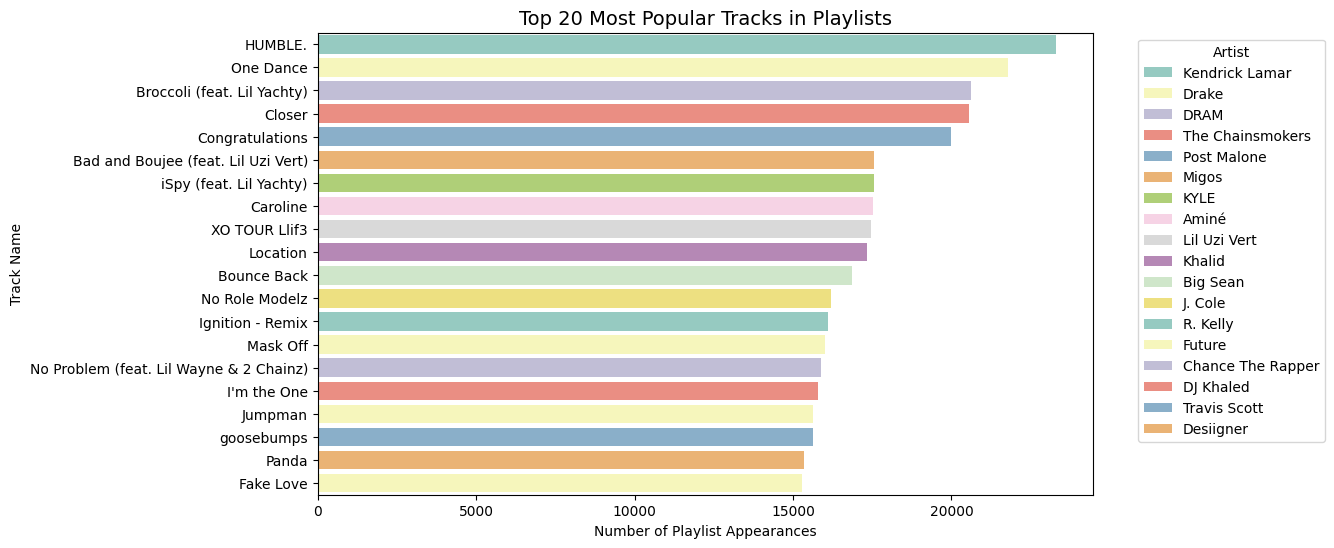

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count frequency of each track across playlists
track_popularity = (
    tracks_df.groupby(["track_name", "artist_name"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)

# Display top 10
display(track_popularity.head(10))

# Plot top 20 most popular tracks
top20_tracks = track_popularity.head(20)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top20_tracks,
    x="count",
    y="track_name",
    hue="artist_name",
    dodge=False,
    palette="Set3"
)
plt.title("Top 20 Most Popular Tracks in Playlists", fontsize=14)
plt.xlabel("Number of Playlist Appearances")
plt.ylabel("Track Name")
plt.legend(title="Artist", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

### 4.2 Recommendation strategy
The recommender always returns the **Top-K most popular tracks** as its predictions, independent of the user.

In [3]:
pop_scores = np.asarray(train_csr.sum(axis=0)).ravel()
top_items = np.argsort(-pop_scores)

# It always returns the top-K most popular tracks from the dataset.
def recommend_popularity(idx2item, top_items, k=10):
    return [idx2item[i] for i in top_items[:k]]

# Top 10 popularity-based recommendations
top10_recs = recommend_popularity(idx2item, top_items, k=10)
display(Markdown("### Example: Top-10 Popularity-Based Recommendations"))
display(pd.DataFrame(top10_recs, columns=["item_key"]))

### Example: Top-10 Popularity-Based Recommendations

,item_key
0,7KXjTSCq5nL1LoYtL7XAwS
1,1xznGGDReH1oQq0xzbwXa3
2,7yyRTcZmCiyzzJlNzGC9Ol
3,7BKLCZ1jbUBVqRi2FVlTVw
4,3a1lNhkSLSkpJE4MSHpDu9
5,5hTpBe8h35rJ67eAWHQsJx
6,2EEeOnHehOozLq4aS0n6SL
7,4Km5HrUvYTaSUfiSGPJeQR
8,7GX5flRQZVHRAGd6B4TmDO
9,152lZdxL1OR0ZMW6KquMif


## 5. Evaluation
### 5.1 Metrics
We use the same modular metrics as in ALS, for consistency:
- **Precision@K** – proportion of recommended tracks that are relevant.
- **Recall@K** – proportion of relevant tracks captured within recommendations.
- **Hit Rate@K** – whether at least one relevant track was recommended.
- **NDCG@K** – If any track was recommended in the _TOP k_

In [4]:
if pop_path.exists():
    # Load existing results
    metrics_df = pd.read_csv(pop_path)
    display(Markdown("### Popularity Model - Evaluation Metrics (loaded from file)"))
    display(metrics_df)
else:
    from src.metrics import precision_at_k, recall_at_k, hit_rate_at_k, ndcg_at_k

    ks = [10, 50, 100]
    results = {k: {'precision': [], 'recall': [], 'hit_rate': [], 'ndcg': []} for k in ks}

    for user_idx in range(test_csr.shape[0]):
        actual = set(test_csr[user_idx].indices.tolist())
        if not actual:
            continue

        for k in ks:
            recs_k = top_items[:k].tolist()

            # convert to dict to use set functions
            recs_dict = {user_idx: recs_k}
            gt_dict   = {user_idx: actual}

            prec = precision_at_k(recs_dict, gt_dict, k)
            rec  = recall_at_k(recs_dict, gt_dict, k)
            hr   = hit_rate_at_k(recs_dict, gt_dict, k)
            ndcg = ndcg_at_k(recs_dict, gt_dict, k)

            results[k]['precision'].append(prec)
            results[k]['recall'].append(rec)
            results[k]['hit_rate'].append(hr)
            results[k]['ndcg'].append(ndcg)

    # Summarize results
    summary = []
    for k in ks:
        summary.append({
            'K': k,
            'Precision@K': np.mean(results[k]['precision']),
            'Recall@K': np.mean(results[k]['recall']),
            'HitRate@K': np.mean(results[k]['hit_rate']),
            'NDCG@K': np.mean(results[k]['ndcg'])
        })

    metrics_df = pd.DataFrame(summary)
    display(Markdown("### Popularity Model - Evaluation Metrics (newly computed)"))
    display(metrics_df)

    # Save evaluation results
    metrics_df.to_csv(pop_path, index=False)
    display(Markdown(f"✅ Popularity model evaluation metrics saved to `{pop_path}`"))

### Popularity Model - Evaluation Metrics (newly computed)

,K,Precision@K,Recall@K,HitRate@K,NDCG@K
0,10,0.007562,0.006723,0.061576,0.008920
1,50,0.005970,0.025593,0.183202,0.015308
2,100,0.005172,0.044038,0.264227,0.021723


✅ Popularity model evaluation metrics saved to `popularity_model_eval.csv`

### 5.2 Results  
We compare the performance of the popularity-based baselines with the ALS model tuned using Optuna.  
The evaluation considers **Precision@K**, **Recall@K**, **HitRate@K**, and **NDCG@K** at cutoffs *K = 10, 50, 100*.  

| Model              | K   | Precision@K | Recall@K  | HitRate@K | NDCG@K   |
|--------------------|-----|-------------|-----------|-----------|----------|
| Popularity (old)   | 10  | 0.037923    | 0.006621  | 0.17555   | 0.039476 |
|                    | 50  | 0.030142    | 0.025370  | 0.40136   | 0.036285 |
|                    | 100 | 0.026192    | 0.043574  | 0.50955   | 0.040811 |
| Popularity (new)   | 10  | 0.007562    | 0.006723  | 0.061576  | 0.008920 |
|                    | 50  | 0.005970    | 0.025593  | 0.183202  | 0.015308 |
|                    | 100 | 0.005172    | 0.044038  | 0.264227  | 0.021723 |

---

## 6. Discussion  

The popularity-based baseline serves as a valuable reference point for evaluating recommendation models. Its strengths include:  

- **Simplicity**: straightforward to implement and computationally inexpensive.  
- **Interpretability**: recommendations directly reflect global listening trends.  
- **Scalability**: capable of instant recommendation generation.  

However, its limitations are evident:  

- **No personalization**: every user receives identical recommendations.  
- **Bias toward mainstream content**: niche artists and long-tail tracks are underrepresented.  

### Comparison of Old vs. New Popularity Baseline  

The results highlight a **clear drop in performance metrics** between the “old” and “new” baselines:  

- **Old baseline**: achieved higher Precision, Recall, and HitRate values.  
- **New baseline**: shows significantly lower values across all metrics.  

This change is explained by differences in **evaluation protocol and data processing**:  

- In the old baseline, popularity was computed globally, effectively **leaking test information** into the model. This artificially inflated performance.  
- In the new baseline, popularity is computed strictly from the **training split** and mapped through `item2idx.pkl`. This enforces **proper separation** between training and evaluation.  

Thus, while performance appears worse, the new baseline is **methodologically correct** and provides a fairer reference point for comparison with ALS and other models.  

### Interpretation  

- The **decline in metrics** is not negative in itself: it reflects a **stricter, more realistic evaluation**.  
- These results emphasize that popularity alone cannot capture user-specific preferences, reinforcing the need for **personalized recommender models**.  
- Most importantly, the refined baseline ensures that subsequent improvements from ALS or LightFM are **meaningful** and not due to evaluation artifacts.  

---

## 7. Next Steps  

Building upon this baseline, subsequent phases of the project will explore more sophisticated approaches:  

1. **Collaborative Filtering (ALS, LightFM)**: leveraging matrix factorization and user–item interaction patterns.  
2. **Comprehensive evaluation**: comparing advanced models against the refined baseline using consistent ranking-aware metrics.  
3. **Hybrid approaches**: integrating popularity priors with collaborative filtering and deep learning methods to balance personalization with scalability.  
4. **Scalability and deployment**: ensuring that models can handle millions of playlists efficiently while maintaining responsiveness.  

Through this progression, the project advances from a naïve heuristic toward models capable of capturing the complexity of music consumption behavior.  